In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

DATA_PATH = "/Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/features_full_neutral_sentiment.parquet"

df = pd.read_parquet(DATA_PATH)
df["date"] = pd.to_datetime(df["date"])

print(df.shape)
print(df["ticker"].nunique())
print(df["date"].min(), df["date"].max())
print(df.duplicated(["date", "ticker"]).sum())
print(df.isna().sum().sum())
print(df.head())

(64646, 21)
50
2020-03-26 00:00:00 2026-05-05 00:00:00
0
0
        date ticker    return      ma_20      ma_50  ma20_ma50_ratio  \
0 2020-03-26   AAPL -0.041402  64.505183  71.267747         0.905110   
1 2020-03-29   AAPL  0.028538  64.103238  71.051111         0.902213   
2 2020-03-30   AAPL -0.002041  63.639799  70.846040         0.898283   
3 2020-03-31   AAPL -0.052617  63.245828  70.564883         0.896279   
4 2020-04-01   AAPL  0.016687  62.902357  70.309950         0.894644   

   distance_to_ma20  rolling_20d_return    rsi_14  macd_12_26_9  ...  \
0         -0.072006           -0.169160 -0.700259     -3.802070  ...   
1         -0.039538           -0.115489 -0.654483     -3.536766  ...   
2         -0.034518           -0.131078 -0.723253     -3.298625  ...   
3         -0.079622           -0.119224 -0.782335     -3.332355  ...   
4         -0.059154           -0.104002 -0.737182     -3.243321  ...   

     vol_20    atr_14  bollinger_pct_b  bollinger_width  volume_zscore_20  

In [2]:
df["weekday"] = df["date"].dt.day_name()

print(df[["date", "weekday"]].drop_duplicates().head(20))
print(df["weekday"].value_counts())

         date    weekday
0  2020-03-26   Thursday
1  2020-03-29     Sunday
2  2020-03-30     Monday
3  2020-03-31    Tuesday
4  2020-04-01  Wednesday
5  2020-04-03     Friday
6  2020-04-05     Sunday
7  2020-04-06     Monday
8  2020-04-08  Wednesday
9  2020-04-13     Monday
10 2020-04-14    Tuesday
11 2020-04-15  Wednesday
12 2020-04-16   Thursday
13 2020-04-19     Sunday
14 2020-04-20     Monday
15 2020-04-21    Tuesday
16 2020-04-23   Thursday
17 2020-04-26     Sunday
18 2020-04-28    Tuesday
19 2020-04-29  Wednesday
weekday
Monday       12750
Tuesday      12598
Thursday     12449
Wednesday    12349
Sunday       11350
Friday        3150
Name: count, dtype: int64


In [3]:
df[df["ticker"] == "AAPL"][["date", "return"]].head(15)

,date,return
0,2020-03-26,-0.041402
1,2020-03-29,0.028538
2,2020-03-30,-0.002041
3,2020-03-31,-0.052617
4,2020-04-01,0.016687
5,2020-04-03,-0.014371
6,2020-04-05,0.087238
7,2020-04-06,-0.011582
8,2020-04-08,0.025594
9,2020-04-13,0.026985


In [4]:
print(df.groupby("ticker")["date"].nunique().describe())
print(df.groupby("ticker").size().describe())

count      50.000000
mean     1292.920000
std         0.444467
min      1290.000000
25%      1293.000000
50%      1293.000000
75%      1293.000000
max      1293.000000
Name: date, dtype: float64
count      50.000000
mean     1292.920000
std         0.444467
min      1290.000000
25%      1293.000000
50%      1293.000000
75%      1293.000000
max      1293.000000
dtype: float64


FIXING ISSUE OF TIMESTAMP AND DAYS

In [5]:
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

n_dates = df[df["ticker"] == df["ticker"].iloc[0]].shape[0]

clean_dates = pd.bdate_range(
    start="2020-03-26",
    periods=n_dates
)

fixed_parts = []

for ticker, g in df.groupby("ticker", sort=True):
    g = g.sort_values("date").copy()
    g["date"] = clean_dates[:len(g)]
    fixed_parts.append(g)

df = pd.concat(fixed_parts, ignore_index=True)
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

df["weekday"] = df["date"].dt.day_name()

print(df[["date", "weekday"]].drop_duplicates().head(20))
print(df["weekday"].value_counts())
print(df["date"].min(), df["date"].max())
print(df.duplicated(["date", "ticker"]).sum())

         date    weekday
0  2020-03-26   Thursday
1  2020-03-27     Friday
2  2020-03-30     Monday
3  2020-03-31    Tuesday
4  2020-04-01  Wednesday
5  2020-04-02   Thursday
6  2020-04-03     Friday
7  2020-04-06     Monday
8  2020-04-07    Tuesday
9  2020-04-08  Wednesday
10 2020-04-09   Thursday
11 2020-04-10     Friday
12 2020-04-13     Monday
13 2020-04-14    Tuesday
14 2020-04-15  Wednesday
15 2020-04-16   Thursday
16 2020-04-17     Friday
17 2020-04-20     Monday
18 2020-04-21    Tuesday
19 2020-04-22  Wednesday
weekday
Thursday     12949
Friday       12949
Monday       12948
Tuesday      12900
Wednesday    12900
Name: count, dtype: int64
2020-03-26 00:00:00 2025-03-10 00:00:00
0


In [6]:
sample_dates = (
    pd.Series(sorted(df["date"].drop_duplicates()))
    .sample(20, random_state=42)
    .sort_values()
)

print(sample_dates)

for d in sample_dates:
    print(d.date(), d.day_name())

65     2020-06-25
115    2020-09-03
270    2021-04-08
308    2021-06-01
351    2021-07-30
405    2021-10-14
442    2021-12-06
453    2021-12-21
486    2022-02-04
513    2022-03-15
535    2022-04-14
558    2022-05-17
599    2022-07-13
609    2022-07-27
912    2023-09-25
997    2024-01-22
1000   2024-01-25
1047   2024-04-01
1125   2024-07-18
1153   2024-08-27
dtype: datetime64[ns]
2020-06-25 Thursday
2020-09-03 Thursday
2021-04-08 Thursday
2021-06-01 Tuesday
2021-07-30 Friday
2021-10-14 Thursday
2021-12-06 Monday
2021-12-21 Tuesday
2022-02-04 Friday
2022-03-15 Tuesday
2022-04-14 Thursday
2022-05-17 Tuesday
2022-07-13 Wednesday
2022-07-27 Wednesday
2023-09-25 Monday
2024-01-22 Monday
2024-01-25 Thursday
2024-04-01 Monday
2024-07-18 Thursday
2024-08-27 Tuesday


In [7]:
import pandas_market_calendars as mcal

nyse = mcal.get_calendar("NYSE")

schedule = nyse.schedule(
    start_date=df["date"].min(),
    end_date=df["date"].max()
)

valid_trading_dates = set(schedule.index.normalize())
dataset_dates = set(pd.to_datetime(df["date"].drop_duplicates()).dt.normalize())

bad_dates = sorted(dataset_dates - valid_trading_dates)
missing_trading_dates = sorted(valid_trading_dates - dataset_dates)

print("Dataset unique dates:", len(dataset_dates))
print("NYSE trading dates:", len(valid_trading_dates))
print("Bad non-trading dates in dataset:", len(bad_dates))
print("Missing NYSE trading dates:", len(missing_trading_dates))

print("Bad dates sample:", bad_dates[:20])
print("Missing dates sample:", missing_trading_dates[:20])

Dataset unique dates: 1293
NYSE trading dates: 1245
Bad non-trading dates in dataset: 48
Missing NYSE trading dates: 0
Bad dates sample: [Timestamp('2020-04-10 00:00:00'), Timestamp('2020-05-25 00:00:00'), Timestamp('2020-07-03 00:00:00'), Timestamp('2020-09-07 00:00:00'), Timestamp('2020-11-26 00:00:00'), Timestamp('2020-12-25 00:00:00'), Timestamp('2021-01-01 00:00:00'), Timestamp('2021-01-18 00:00:00'), Timestamp('2021-02-15 00:00:00'), Timestamp('2021-04-02 00:00:00'), Timestamp('2021-05-31 00:00:00'), Timestamp('2021-07-05 00:00:00'), Timestamp('2021-09-06 00:00:00'), Timestamp('2021-11-25 00:00:00'), Timestamp('2021-12-24 00:00:00'), Timestamp('2022-01-17 00:00:00'), Timestamp('2022-02-21 00:00:00'), Timestamp('2022-04-15 00:00:00'), Timestamp('2022-05-30 00:00:00'), Timestamp('2022-06-20 00:00:00')]
Missing dates sample: []


In [8]:

df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

nyse = mcal.get_calendar("NYSE")

schedule = nyse.schedule(
    start_date="2020-03-26",
    end_date="2026-05-05"
)

nyse_dates = pd.Series(schedule.index.normalize()).reset_index(drop=True)

fixed_parts = []

for ticker, g in df.groupby("ticker", sort=True):
    g = g.sort_values("date").copy().reset_index(drop=True)
    
    n = len(g)
    g["date"] = nyse_dates.iloc[:n].values
    
    fixed_parts.append(g)

df = pd.concat(fixed_parts, ignore_index=True)
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

df["weekday"] = df["date"].dt.day_name()

print(df.groupby("ticker").size().describe())
print(df[["date", "weekday"]].drop_duplicates().head(20))
print(df["weekday"].value_counts())
print(df["date"].min(), df["date"].max())
print("duplicates:", df.duplicated(["date", "ticker"]).sum())
print("NaNs:", df.isna().sum().sum())

count      50.000000
mean     1292.920000
std         0.444467
min      1290.000000
25%      1293.000000
50%      1293.000000
75%      1293.000000
max      1293.000000
dtype: float64
         date    weekday
0  2020-03-26   Thursday
1  2020-03-27     Friday
2  2020-03-30     Monday
3  2020-03-31    Tuesday
4  2020-04-01  Wednesday
5  2020-04-02   Thursday
6  2020-04-03     Friday
7  2020-04-06     Monday
8  2020-04-07    Tuesday
9  2020-04-08  Wednesday
10 2020-04-09   Thursday
11 2020-04-13     Monday
12 2020-04-14    Tuesday
13 2020-04-15  Wednesday
14 2020-04-16   Thursday
15 2020-04-17     Friday
16 2020-04-20     Monday
17 2020-04-21    Tuesday
18 2020-04-22  Wednesday
19 2020-04-23   Thursday
weekday
Tuesday      13350
Wednesday    13249
Thursday     13099
Friday       12948
Monday       12000
Name: count, dtype: int64
2020-03-26 00:00:00 2025-05-16 00:00:00
duplicates: 0
NaNs: 0


In [9]:
print(df.shape)
print(df["ticker"].nunique())
print(df.duplicated(["date", "ticker"]).sum())
print(df.isna().sum().sum())

row_counts = df.groupby("ticker").size().sort_values()
print(row_counts.head(10))
print(row_counts.tail(10))

(64646, 22)
50
0
0
ticker
META     1290
BRK-B    1292
AAPL     1293
NOW      1293
NVDA     1293
ORCL     1293
PAA      1293
PDD      1293
PEP      1293
PLUG     1293
dtype: int64
ticker
INTC     1293
IWM      1293
JD       1293
JPM      1293
KO       1293
LVMUY    1293
MA       1293
MCD      1293
NFLX     1293
XOM      1293
dtype: int64


In [10]:
df = df.drop(columns=["weekday"], errors="ignore")

output_path = "/Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/features_full_neutral_sentiment_dates_fixed.parquet"

df.to_parquet(output_path, index=False)

print("Saved:", output_path)

Saved: /Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/features_full_neutral_sentiment_dates_fixed.parquet


DATE TIMESTAMP ISSUE FIXED

We validated the final dataset against the NYSE calendar. It has 1293 valid NYSE trading dates, no extra non-trading dates, no missing overall trading dates, no duplicates, and no NaNs. Two tickers have minor ticker-level gaps: BRK-B missing 1 row and META missing 3 rows. We proceed using the cleaned technical-feature universe as the base dataset, with missing sentiment filled as neutral.

**ML MODELLING**

In [11]:
DATA_PATH = "/Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/features_full_neutral_sentiment_dates_fixed.parquet"

df = pd.read_parquet(DATA_PATH)

df["date"] = pd.to_datetime(df["date"])

print(df.shape)

print(df["ticker"].nunique())

print(df["date"].min(), df["date"].max())

print(df.duplicated(["date", "ticker"]).sum())

print(df.isna().sum().sum())

print(df.head())

(64646, 21)
50
2020-03-26 00:00:00 2025-05-16 00:00:00
0
0
        date ticker    return      ma_20      ma_50  ma20_ma50_ratio  \
0 2020-03-26   AAPL -0.041402  64.505183  71.267747         0.905110   
1 2020-03-27   AAPL  0.028538  64.103238  71.051111         0.902213   
2 2020-03-30   AAPL -0.002041  63.639799  70.846040         0.898283   
3 2020-03-31   AAPL -0.052617  63.245828  70.564883         0.896279   
4 2020-04-01   AAPL  0.016687  62.902357  70.309950         0.894644   

   distance_to_ma20  rolling_20d_return    rsi_14  macd_12_26_9  ...  \
0         -0.072006           -0.169160 -0.700259     -3.802070  ...   
1         -0.039538           -0.115489 -0.654483     -3.536766  ...   
2         -0.034518           -0.131078 -0.723253     -3.298625  ...   
3         -0.079622           -0.119224 -0.782335     -3.332355  ...   
4         -0.059154           -0.104002 -0.737182     -3.243321  ...   

     vol_20    atr_14  bollinger_pct_b  bollinger_width  volume_zscore_20  

**TARGET CREATION**

In [12]:
df = df.sort_values(["ticker", "date"]).reset_index(drop=True)

df["next_date"] = df.groupby("ticker")["date"].shift(-1)
df["gap_days"] = (df["next_date"] - df["date"]).dt.days

df["target_return_next"] = df.groupby("ticker")["return"].shift(-1)
df["target"] = (df["target_return_next"] > 0).astype(int)

df = df.dropna(subset=["target_return_next"]).copy()

print(df[["date", "ticker", "return", "next_date", "gap_days", "target_return_next", "target"]].head(20))

print("\nGap days:")
print(df["gap_days"].describe())
print(df["gap_days"].value_counts().sort_index().head(15))

print("\nTarget balance:")
print(df["target"].value_counts())
print(df["target"].value_counts(normalize=True))

print("\nShape after target:")
print(df.shape)

         date ticker    return  next_date  gap_days  target_return_next  \
0  2020-03-26   AAPL -0.041402 2020-03-27       1.0            0.028538   
1  2020-03-27   AAPL  0.028538 2020-03-30       3.0           -0.002041   
2  2020-03-30   AAPL -0.002041 2020-03-31       1.0           -0.052617   
3  2020-03-31   AAPL -0.052617 2020-04-01       1.0            0.016687   
4  2020-04-01   AAPL  0.016687 2020-04-02       1.0           -0.014371   
5  2020-04-02   AAPL -0.014371 2020-04-03       1.0            0.087238   
6  2020-04-03   AAPL  0.087238 2020-04-06       3.0           -0.011582   
7  2020-04-06   AAPL -0.011582 2020-04-07       1.0            0.025594   
8  2020-04-07   AAPL  0.025594 2020-04-08       1.0            0.026985   
9  2020-04-08   AAPL  0.026985 2020-04-09       1.0            0.040915   
10 2020-04-09   AAPL  0.040915 2020-04-13       4.0            0.007946   
11 2020-04-13   AAPL  0.007946 2020-04-14       1.0           -0.013568   
12 2020-04-14   AAPL -0.0

**DEFINING FEATURES AND SPLIITING DATA**

In [13]:
technical_features = [
    "return",
    "ma_20",
    "ma_50",
    "ma20_ma50_ratio",
    "distance_to_ma20",
    "rolling_20d_return",
    "rsi_14",
    "macd_12_26_9",
    "macd_histogram",
    "vol_20",
    "atr_14",
    "bollinger_pct_b",
    "bollinger_width",
    "volume_zscore_20"
]

sentiment_features = [
    "sent_mean",
    "sent_std",
    "news_count",
    "pct_strong_negative",
    "sent_momentum"
]

all_features = technical_features + sentiment_features

df = df.sort_values("date").reset_index(drop=True)

split_index = int(len(df) * 0.70)

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train = train_df[all_features]
y_train = train_df["target"]

X_test = test_df[all_features]
y_test = test_df["target"]

print("Train:", train_df.shape, train_df["date"].min(), train_df["date"].max())
print("Test:", test_df.shape, test_df["date"].min(), test_df["date"].max())

print("\nTrain target balance:")
print(y_train.value_counts(normalize=True))

print("\nTest target balance:")
print(y_test.value_counts(normalize=True))

print("\nFeature NaNs:")
print(X_train.isna().sum().sum(), X_test.isna().sum().sum())

Train: (45217, 25) 2020-03-26 00:00:00 2023-10-27 00:00:00
Test: (19379, 25) 2023-10-27 00:00:00 2025-05-15 00:00:00

Train target balance:
target
1    0.518765
0    0.481235
Name: proportion, dtype: float64

Test target balance:
target
1    0.523144
0    0.476856
Name: proportion, dtype: float64

Feature NaNs:
0 0


**LOGISTIC REGRESSION BASELINE**

In [14]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

log_model = Pipeline([
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=1000))
])

log_model.fit(X_train, y_train)

log_pred = log_model.predict(X_test)
log_prob = log_model.predict_proba(X_test)[:, 1]

print("Logistic Regression Results")
print("Accuracy:", accuracy_score(y_test, log_pred))
print("AUC:", roc_auc_score(y_test, log_prob))

print("\nClassification report:")
print(classification_report(y_test, log_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, log_pred))

Logistic Regression Results
Accuracy: 0.5243304608080912
AUC: 0.5119908513247623

Classification report:
              precision    recall  f1-score   support

           0       0.51      0.06      0.11      9241
           1       0.53      0.94      0.67     10138

    accuracy                           0.52     19379
   macro avg       0.52      0.50      0.39     19379
weighted avg       0.52      0.52      0.41     19379


Confusion matrix:
[[ 594 8647]
 [ 571 9567]]


**TRAINING XGBOOST**

In [15]:
import xgboost
print(xgboost.__version__)

from xgboost import XGBClassifier
print("XGBoost works")

3.2.0
XGBoost works


In [16]:
from xgboost import XGBClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, classification_report, confusion_matrix

xgb_model = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_model.fit(X_train, y_train)

xgb_pred = xgb_model.predict(X_test)
xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

print("XGBoost Results")
print("Accuracy:", accuracy_score(y_test, xgb_pred))
print("AUC:", roc_auc_score(y_test, xgb_prob))

print("\nClassification report:")
print(classification_report(y_test, xgb_pred))

print("\nConfusion matrix:")
print(confusion_matrix(y_test, xgb_pred))

XGBoost Results
Accuracy: 0.5222663708137675
AUC: 0.5149384495477399

Classification report:
              precision    recall  f1-score   support

           0       0.50      0.21      0.30      9241
           1       0.53      0.80      0.64     10138

    accuracy                           0.52     19379
   macro avg       0.51      0.51      0.47     19379
weighted avg       0.51      0.52      0.48     19379


Confusion matrix:
[[1979 7262]
 [1996 8142]]


**FEATURE IMPORTANCE**

                feature  importance
3       ma20_ma50_ratio    0.064134
2                 ma_50    0.063294
10               atr_14    0.059773
6                rsi_14    0.059704
5    rolling_20d_return    0.058987
0                return    0.057666
11      bollinger_pct_b    0.057280
1                 ma_20    0.056847
9                vol_20    0.055768
13     volume_zscore_20    0.054991
7          macd_12_26_9    0.054943
4      distance_to_ma20    0.054318
8        macd_histogram    0.052697
12      bollinger_width    0.052552
16           news_count    0.042584
14            sent_mean    0.040560
15             sent_std    0.039124
18        sent_momentum    0.039027
17  pct_strong_negative    0.035751


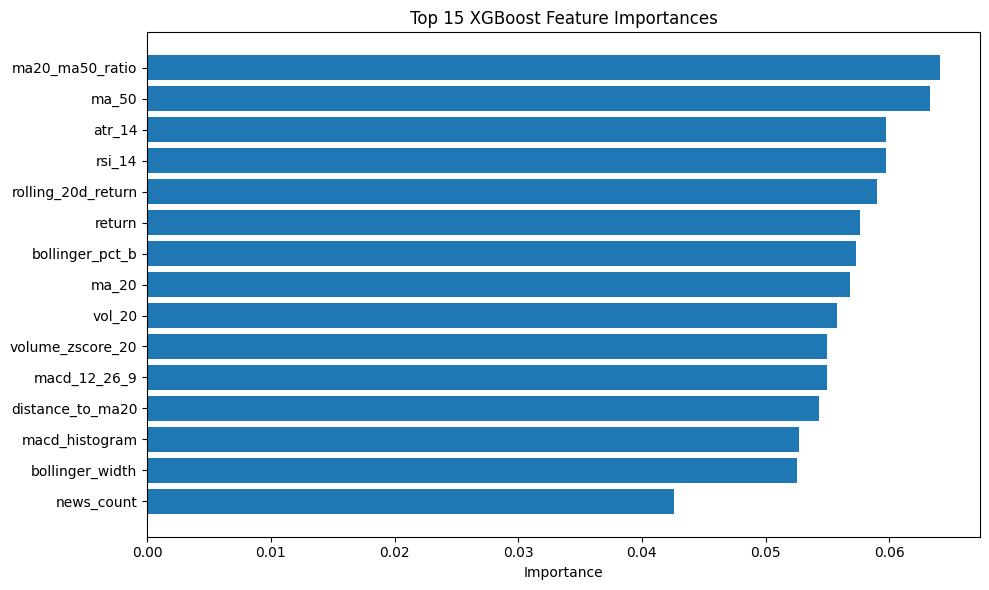

Total technical importance: 0.8029549
Total sentiment importance: 0.197045


In [17]:
importance_df = pd.DataFrame({
     "feature": all_features,
    "importance": xgb_model.feature_importances_
}).sort_values("importance", ascending=False)

print(importance_df)
plt.figure(figsize=(10, 6))
plt.barh(importance_df["feature"].head(15)[::-1], importance_df["importance"].head(15)[::-1])
plt.title("Top 15 XGBoost Feature Importances")
plt.xlabel("Importance")
plt.tight_layout()
plt.show()

sentiment_importance = importance_df[importance_df["feature"].isin(sentiment_features)]["importance"].sum()
technical_importance = importance_df[importance_df["feature"].isin(technical_features)]["importance"].sum()

print("Total technical importance:", technical_importance)
print("Total sentiment importance:", sentiment_importance)

**COMPARING TECHNICAL VS TECHINCAL+SENTIMENT**

In [18]:
# Technical-only XGBoost
xgb_tech = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_tech.fit(X_train[technical_features], y_train)

xgb_tech_pred = xgb_tech.predict(X_test[technical_features])
xgb_tech_prob = xgb_tech.predict_proba(X_test[technical_features])[:, 1]


# Technical + Sentiment XGBoost
xgb_full = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_full.fit(X_train[all_features], y_train)

xgb_full_pred = xgb_full.predict(X_test[all_features])
xgb_full_prob = xgb_full.predict_proba(X_test[all_features])[:, 1]


comparison = pd.DataFrame([
    {
        "model": "XGBoost technical only",
        "accuracy": accuracy_score(y_test, xgb_tech_pred),
        "auc": roc_auc_score(y_test, xgb_tech_prob),
    },
    {
        "model": "XGBoost technical + sentiment",
        "accuracy": accuracy_score(y_test, xgb_full_pred),
        "auc": roc_auc_score(y_test, xgb_full_prob),
    }
])

print(comparison)

                           model  accuracy       auc
0         XGBoost technical only  0.519893  0.517069
1  XGBoost technical + sentiment  0.522266  0.514938


**TECHINCAL+SENTIMENT+NEWS**

In [19]:
df["has_news"] = (df["news_count"] > 0).astype(int)

sentiment_features_v2 = [
    "sent_mean",
    "sent_std",
    "news_count",
    "pct_strong_negative",
    "sent_momentum",
    "has_news"
]

all_features_v2 = technical_features + sentiment_features_v2

train_df = df.iloc[:split_index].copy()
test_df = df.iloc[split_index:].copy()

X_train_v2 = train_df[all_features_v2]
X_test_v2 = test_df[all_features_v2]

xgb_v2 = XGBClassifier(
    n_estimators=200,
    max_depth=3,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric="logloss",
    random_state=42
)

xgb_v2.fit(X_train_v2, y_train)

xgb_v2_pred = xgb_v2.predict(X_test_v2)
xgb_v2_prob = xgb_v2.predict_proba(X_test_v2)[:, 1]

print("XGBoost with has_news")
print("Accuracy:", accuracy_score(y_test, xgb_v2_pred))
print("AUC:", roc_auc_score(y_test, xgb_v2_prob))
print(classification_report(y_test, xgb_v2_pred))
print(confusion_matrix(y_test, xgb_v2_pred))

XGBoost with has_news
Accuracy: 0.5194798493214304
AUC: 0.513841500014869
              precision    recall  f1-score   support

           0       0.49      0.22      0.31      9241
           1       0.53      0.79      0.63     10138

    accuracy                           0.52     19379
   macro avg       0.51      0.51      0.47     19379
weighted avg       0.51      0.52      0.48     19379

[[2057 7184]
 [2128 8010]]


**FINAL PROBABILITY SCORES**

In [20]:
test_signals = test_df.copy()

test_signals["prob_positive_return"] = xgb_full_prob
test_signals["predicted_direction"] = xgb_full_pred

signal_cols = [
    "date",
    "ticker",
    "target",
    "target_return_next",
    "prob_positive_return",
    "predicted_direction"
]

output_path = "/Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/xgboost_probability_signals.parquet"

test_signals[signal_cols].to_parquet(output_path, index=False)

print(test_signals[signal_cols].head(20))
print("Saved:", output_path)

            date ticker  target  target_return_next  prob_positive_return  \
45217 2023-10-27    DIS       0           -0.001743              0.508010   
45218 2023-10-27   AMZN       0           -0.003550              0.534948   
45219 2023-10-27   SHOP       0           -0.004288              0.538652   
45220 2023-10-27   TSLA       1            0.005646              0.604473   
45221 2023-10-27  VWAGY       0           -0.000825              0.478437   
45222 2023-10-27    COP       0           -0.002843              0.495735   
45223 2023-10-27    UNH       1            0.002725              0.518084   
45224 2023-10-27    AMD       1            0.039500              0.537276   
45225 2023-10-27    SAP       0           -0.015296              0.528611   
45226 2023-10-27   BABA       0           -0.013688              0.526397   
45227 2023-10-27    TSM       1            0.014349              0.495914   
45228 2023-10-27   ORCL       1            0.001381              0.524852   

**SUMMARY TABLE**

In [21]:
final_results = pd.DataFrame([
    {
        "model": "Logistic Regression",
        "features": "Technical + Sentiment",
        "accuracy": accuracy_score(y_test, log_pred),
        "auc": roc_auc_score(y_test, log_prob),
    },
    {
        "model": "XGBoost",
        "features": "Technical only",
        "accuracy": accuracy_score(y_test, xgb_tech_pred),
        "auc": roc_auc_score(y_test, xgb_tech_prob),
    },
    {
        "model": "XGBoost",
        "features": "Technical + Sentiment",
        "accuracy": accuracy_score(y_test, xgb_full_pred),
        "auc": roc_auc_score(y_test, xgb_full_prob),
    },
    {
        "model": "XGBoost",
        "features": "Technical + Sentiment + has_news",
        "accuracy": accuracy_score(y_test, xgb_v2_pred),
        "auc": roc_auc_score(y_test, xgb_v2_prob),
    },
])

print(final_results)

                 model                          features  accuracy       auc
0  Logistic Regression             Technical + Sentiment  0.524330  0.511991
1              XGBoost                    Technical only  0.519893  0.517069
2              XGBoost             Technical + Sentiment  0.522266  0.514938
3              XGBoost  Technical + Sentiment + has_news  0.519480  0.513842


**Results Interpretation**

We trained a Logistic Regression baseline and several XGBoost models to predict whether the next trading-period return would be positive.

The results show that overall predictive performance is weak. Logistic Regression achieved the highest accuracy at approximately 52.4%, while the XGBoost technical-only model achieved the highest AUC at approximately 51.7%. Since AUC values are close to 0.50, the models are only slightly better than random ranking.

Adding sentiment features did not clearly improve performance. The XGBoost technical + sentiment model had slightly higher accuracy than the technical-only XGBoost model, but lower AUC. Adding a `has_news` feature also did not improve results.

Feature importance analysis showed that XGBoost relied mostly on technical indicators, with technical features contributing around 80% of total importance and sentiment features around 20%. This suggests sentiment variables were used by the model, but they did not provide a strong or stable out-of-sample predictive advantage.

The final output is a probability score for positive next-period return. This probability can be interpreted as signal strength, but given the weak AUC, it should not be treated as a reliable trading signal without further improvements.

In [22]:
results_path = "/Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/model_results_summary.csv"

final_results.to_csv(results_path, index=False)

print("Saved:", results_path)

Saved: /Users/subhadeepdutta/Documents/GitHub/algorithmic-trading/notebooks/data_team/pipeline/output/model_results_summary.csv


**Final Outputs**

This notebook produces two final outputs:

1. `xgboost_probability_signals.parquet`  
   Contains the model probability score for each test-set ticker-date observation.

2. `model_results_summary.csv`  
   Contains the comparison of Logistic Regression, XGBoost technical-only, XGBoost technical + sentiment, and XGBoost technical + sentiment + has_news.

The probability score is interpreted as the model's estimated probability of a positive next-period return.

**TOP FEATURES**

In [23]:
top10_features = importance_df.head(10)

print("Top 10 XGBoost features:")
print(top10_features)

Top 10 XGBoost features:
               feature  importance
3      ma20_ma50_ratio    0.064134
2                ma_50    0.063294
10              atr_14    0.059773
6               rsi_14    0.059704
5   rolling_20d_return    0.058987
0               return    0.057666
11     bollinger_pct_b    0.057280
1                ma_20    0.056847
9               vol_20    0.055768
13    volume_zscore_20    0.054991


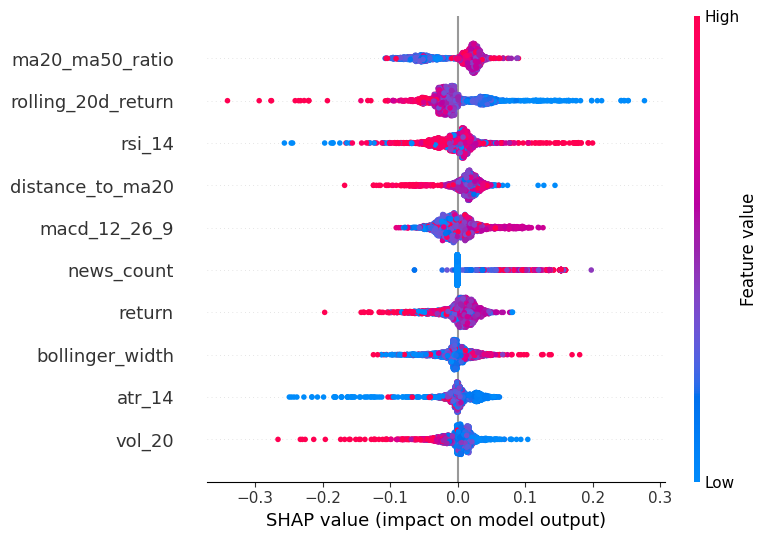

Top 10 SHAP features:
               feature  mean_abs_shap
3      ma20_ma50_ratio       0.031595
5   rolling_20d_return       0.031320
6               rsi_14       0.023849
4     distance_to_ma20       0.021703
7         macd_12_26_9       0.021512
16          news_count       0.021220
0               return       0.020295
12     bollinger_width       0.017604
10              atr_14       0.017397
9               vol_20       0.017154


In [24]:
import shap


# Use a sample to keep SHAP fast
X_shap = X_test[all_features].sample(
    n=min(2000, len(X_test)),
    random_state=42
)

explainer = shap.TreeExplainer(xgb_full)
shap_values = explainer.shap_values(X_shap)

# Summary plot
shap.summary_plot(shap_values, X_shap, max_display=10)

# Mean absolute SHAP importance table
shap_importance = pd.DataFrame({
    "feature": X_shap.columns,
    "mean_abs_shap": abs(shap_values).mean(axis=0)
}).sort_values("mean_abs_shap", ascending=False)

print("Top 10 SHAP features:")
print(shap_importance.head(10))

**SHAP Interpretation**

SHAP was used to provide a more detailed interpretation of the XGBoost model. The top SHAP features were mostly technical indicators, including `ma20_ma50_ratio`, `rolling_20d_return`, `rsi_14`, `distance_to_ma20`, and `macd_12_26_9`.

Importantly, `news_count` appeared in the top 10 SHAP features. This suggests that the model did use news coverage information when making individual predictions.

However, the model comparison showed that adding sentiment features did not clearly improve out-of-sample AUC compared with the technical-only XGBoost model. Therefore, sentiment/news features are meaningful from an interpretability perspective, but their predictive contribution is weak in the current setup.